# Notebook 4 (v2) - Robustness sweeps + fate readout

**Goal.** Three controlled perturbations of the easy bifurcation, each spanning a small
parameter sweep:

1. **Geometry noise** — synthetic Gaussian noise added when building the data
   (`noise_level ∈ {0.05, 0.10, 0.20, 0.35, 0.50}`).
2. **Branch-density imbalance** — multiplicative factor on Branch_1 cell count
   (`imbalance ∈ {0.25, 0.5, 1, 2, 4}`).
3. **Pseudotime corruption** — Gaussian noise added to the *true* pseudotime that
   anchors the OT windows (`σ ∈ {0, 0.05, 0.1, 0.2}`).

After fitting VelOT we integrate `n_trajectories` forward trajectories from the *Root*
cluster (via `velot.tl.compute_trajectories`) and read out the **terminal reach
probabilities** for `Root / Branch_1 / Branch_2`. From these we derive the **Shannon
entropy** of fate — a model-free metric of branching uncertainty.

**Outputs:**
- Master 3 × 3 robustness panel (one row per sweep × three columns: metrics, reach,
  fate entropy).
- Tipping-point heatmap of reach probabilities.
- Streamline+trajectory field gallery for representative perturbation levels.
- Sankey-style alluvial diagram of trajectory routing.
- Statistical tests for monotonic trends (Spearman ρ) per metric × sweep.

In [1]:
from pathlib import Path
import math
import os, sys, warnings, importlib.util, json, time, subprocess, warnings

warnings.filterwarnings("ignore")

REQUIRED_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "anndata": "anndata",
    "scanpy": "scanpy",
    "ot": "POT",
    "torch": "torch",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_IMPORTS.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ImportError(
        "Missing packages:\n"
        + "\n".join(missing)
        + "\n\nInstall them manually with:\n"
        + f"pip install {' '.join(missing)}"
    )

# Import torch BEFORE velot
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Locate VelOT root
PROJECT_ROOT = Path.cwd().resolve()

CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    PROJECT_ROOT.parent.parent,
]

VELOT_IMPORT_ROOT = None

for c in CANDIDATES:
    if (c / "velot").is_dir():
        VELOT_IMPORT_ROOT = c
        sys.path.insert(0, str(c))
        break

import velot

print(f"VelOT : {getattr(velot, '__version__', 'unknown')}")
print(f"Torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
print(f"CWD   : {PROJECT_ROOT}")
print(f"VelOT import root: {VELOT_IMPORT_ROOT}")

VelOT : 0.1.0
Torch : 2.7.1+cu118
CUDA  : True
CWD   : /home/user/Documents/velot/notebooks/supplementary
VelOT import root: /home/user/Documents/velot


In [2]:
# Publication style — Nature/NMETH defaults with a Wong colourblind-safe palette.
RUN_ROOT = PROJECT_ROOT / "results_velot_publication_v4"
FIGDIR   = RUN_ROOT / "figures"
TABLEDIR = RUN_ROOT / "tables"
JSONDIR  = RUN_ROOT / "json"
for d in (FIGDIR, TABLEDIR, JSONDIR): d.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.transparent": False,
    # "font.family": "serif",
    # "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman"],
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 12, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.frameon": False, "legend.handlelength": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "lines.linewidth": 1.2, "lines.markersize": 5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.prop_cycle": plt.cycler("color",
        ["#0072B2","#D55E00","#009E73","#CC79A7","#F0E442","#56B4E9","#E69F00","#332288"]),
})

# Wong palette (colourblind-safe, used as named colours throughout)
WONG = {
    "blue":   "#0072B2", "orange": "#D55E00", "green":  "#009E73",
    "magenta":"#CC79A7", "yellow": "#F0E442", "skyblue":"#56B4E9",
    "amber":  "#E69F00", "purple": "#332288", "grey":   "#999999",
    "black":  "#000000", "red":    "#882255", "teal":   "#117733",
}

# Semantic colour roles
ROLE = {
    "gpu":      WONG["blue"],
    "cpu1":     WONG["orange"],
    "cpu8":     WONG["amber"],
    "baseline": WONG["green"],
    "ablation": WONG["purple"],
    "primary":  WONG["blue"],
    "secondary":WONG["magenta"],
    "accent":   WONG["green"],
    "neutral":  WONG["grey"],
    "Root":     WONG["grey"],
    "Branch_1": WONG["blue"],
    "Branch_2": WONG["orange"],
}

def panel_label(ax, letter, x=-0.18, y=1.05, fontsize=12, **kw):
    """Add a bold sans-serif (a)/(b)/(c) panel label in figure-corner style."""
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold", va="bottom", ha="left",
            family="sans-serif", **kw)

def savefig(fig, stem, folder=None, close=False):
    """Save both PDF (vector, editable in Illustrator) and PNG (300 dpi)."""
    folder = Path(folder) if folder else FIGDIR
    folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(folder / f"{stem}.png", bbox_inches="tight")
    print(f"saved: {folder / stem}.{{pdf,png}}")
    if close: plt.close(fig)

def add_significance_bracket(ax, x1, x2, y, text, color="black",
                              line_kw=None, text_kw=None):
    """Draw a horizontal significance bracket between x1 and x2 at y, with text above."""
    line_kw = {"lw": 0.9, "color": color, **(line_kw or {})}
    text_kw = {"ha": "center", "va": "bottom", "fontsize": 8,
               "color": color, **(text_kw or {})}
    dy = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], **line_kw)
    ax.text((x1 + x2) / 2, y + dy * 1.1, text, **text_kw)

def stars(p):
    """ASA-style significance stars."""
    if   p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else:          return "ns"


In [3]:
# Easy synthetic bifurcation — identical parameterisation to the working notebooks
# so that figures and timing here are directly comparable to those reports.
BASE_DENSITIES = {
    "root_density":     400,
    "root_position":    3.0,
    "branch_densities": (300, 400),
    "branch_positions": (5.0, 10.0),
    "branch_slopes":    (1.0, -1.0),
    "noise_level":      0.2,
    "extra_dimensions": 1,
    "n_neighbors":      50,
}
EDGES = [("Root", "Branch_1"), ("Root", "Branch_2")]
TERMINALS = ["Root", "Branch_1", "Branch_2"]

def build_easy_bifurcation(seed=42, density_scale=1.0,
                           noise_level=None, imbalance=None, n_neighbors=None):
    """Build the easy synthetic bifurcation used throughout these notebooks."""
    p = dict(BASE_DENSITIES)
    if noise_level is not None: p["noise_level"] = float(noise_level)
    if n_neighbors is not None: p["n_neighbors"] = int(n_neighbors)
    root = max(20, int(round(p["root_density"] * density_scale)))
    b1, b2 = p["branch_densities"]
    b1 = max(20, int(round(b1 * density_scale)))
    b2 = max(20, int(round(b2 * density_scale)))
    if imbalance is not None:
        b1 = max(20, int(round(b1 * float(imbalance))))
    adata = velot.datasets.synthetic_bifurcation(
        root_density=root, root_position=p["root_position"],
        branch_densities=(b1, b2), branch_positions=p["branch_positions"],
        branch_slopes=p["branch_slopes"], noise_level=p["noise_level"],
        extra_dimensions=p["extra_dimensions"], n_neighbors=p["n_neighbors"],
        seed=seed,
    )
    velot.pp.pseudotime(adata, key="true_pseudotime")
    adata.obs["clusters_id"]  = adata.obs["celltype"].cat.codes.astype(int)
    adata.obs["celltype_str"] = adata.obs["celltype"].astype(str)
    return adata

In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

def scalar_metrics_from_results(results):
    out = {k: float(results.get(k, np.nan))
           for k in ("iccoh_mean", "iccoh_median", "cbdir_mean", "cbdir_median")}
    out["quality_mean"] = float(np.nanmean([out["iccoh_mean"], out["cbdir_mean"]]))
    return out

def confidence_summary(adata):
    conf = np.asarray(adata.obs.get("velot_confidence",
                                    np.full(adata.n_obs, np.nan)), dtype=float)
    return {"confidence_mean":   float(np.nanmean(conf)),
            "confidence_median": float(np.nanmedian(conf)),
            "confidence_zero_frac": float(np.mean(conf <= 0))}

def future_alignment_score(adata, basis_key="X_pca",
                           velocity_key="velot_velocity_pca",
                           k=25, min_dt=0.01):
    """Local alignment of velocity to pseudotime-future neighbours."""
    X = np.asarray(adata.obsm[basis_key])
    V = np.asarray(adata.obsm[velocity_key])
    pt = np.asarray(adata.obs["true_pseudotime"].values, dtype=float)
    nn_ = NearestNeighbors(n_neighbors=min(max(k * 4, k + 1), adata.n_obs)).fit(X)
    _, idx = nn_.kneighbors(X)
    scores = []
    for i in range(adata.n_obs):
        cand = idx[i]; cand = cand[pt[cand] > pt[i] + min_dt]
        cand = cand[cand != i]
        if len(cand) == 0: continue
        cand = cand[:k]
        target = X[cand].mean(axis=0) - X[i]
        d = np.linalg.norm(target) * np.linalg.norm(V[i])
        if d > 1e-12:
            scores.append(float(np.dot(target, V[i]) / d))
    return float(np.nanmean(scores)) if scores else np.nan

def run_velot_once(name="baseline", seed=42, density_scale=1.0,
                   noise_level=None, imbalance=None,
                   basis="X_pca", spatial_key="clusters_id", n_clusters=None,
                   window_size=100, overlap_fraction=0.0, min_window_size=20,
                   reg=0.05, lambda_time=1.0, lambda_knn=1.0,
                   smooth=True, n_epochs=300, hidden_dim=128,
                   lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
                   k_smooth=15, use_pseudotime=True, project_umap=True, verbose=False):
    """Run VelOT stage-by-stage; return (adata, record_dict, raw_metrics)."""
    adata = build_easy_bifurcation(seed=seed, density_scale=density_scale,
                                   noise_level=noise_level, imbalance=imbalance)
    times = {}
    def tic(stage):
        s = time.perf_counter()
        return lambda: times.__setitem__(stage, time.perf_counter() - s)

    stop = tic("build_windows")
    velot.tl.build_windows(adata, basis=basis, n_clusters=n_clusters,
                           window_size=window_size, overlap_fraction=overlap_fraction,
                           min_window_size=min_window_size, spatial_key=spatial_key,
                           random_state=seed); stop()

    stop = tic("ot")
    velot.tl.compute_ot_velocity(adata, basis=basis, reg=reg,
                                 lambda_time=lambda_time, lambda_knn=lambda_knn); stop()

    raw_key = "velot_velocity_raw_pca" if basis == "X_pca" else "velot_velocity_raw_umap"
    velocity_key_pca = raw_key

    if smooth:
        stop = tic("smooth")
        velot.tl.smooth_velocity(adata, basis=basis.split("X_")[1],
                                 velocity_key=raw_key, n_epochs=n_epochs,
                                 hidden_dim=hidden_dim, lambda_smooth=lambda_smooth,
                                 lambda_curl=lambda_curl, lambda_divergence=lambda_divergence,
                                 k_smooth=k_smooth, use_pseudotime=use_pseudotime,
                                 random_state=seed, verbose=verbose); stop()
        velocity_key_pca = "velot_velocity_pca" if basis == "X_pca" else "velot_velocity_umap"
    else:
        times["smooth"] = 0.0

    if project_umap and basis == "X_pca":
        stop = tic("project_umap")
        if smooth:
            velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap")
            velocity_key_umap = "velot_velocity_umap"
        else:
            velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", "velot_velocity_raw_umap")
            velocity_key_umap = "velot_velocity_raw_umap"
        stop()
    elif basis == "X_umap":
        velocity_key_umap = velocity_key_pca; times["project_umap"] = 0.0
    else:
        velocity_key_umap = None;             times["project_umap"] = np.nan

    stop = tic("metrics")
    results = velot.metrics.summary(adata, cluster_edges=EDGES,
                                    cluster_key="celltype",
                                    embedding_key="X_umap",
                                    velocity_key=velocity_key_umap); stop()

    rec = dict(name=name, seed=seed, n_cells=int(adata.n_obs),
               basis=basis, spatial_key=str(spatial_key),
               n_clusters=n_clusters if n_clusters is not None else np.nan,
               window_size=int(window_size), overlap_fraction=float(overlap_fraction),
               reg=float(reg), lambda_time=float(lambda_time),
               lambda_knn=float(lambda_knn), smooth=bool(smooth),
               n_epochs=int(n_epochs), hidden_dim=int(hidden_dim),
               lambda_smooth=float(lambda_smooth), lambda_curl=float(lambda_curl),
               lambda_divergence=float(lambda_divergence),
               k_smooth=int(k_smooth), use_pseudotime=bool(use_pseudotime),
               n_window_pairs=int(adata.uns.get("velot_windows", {}).get("n_pairs", 0)),
               device=str(adata.uns.get("velot_smoothing", {}).get("device", "raw/no_smoothing")))
    rec.update({f"time_{k}": float(v) for k, v in times.items()})
    rec["time_total"] = float(np.nansum(list(times.values())))
    rec.update(scalar_metrics_from_results(results))
    rec.update(confidence_summary(adata))
    try:
        rec["future_alignment"] = future_alignment_score(
            adata, "X_pca",
            "velot_velocity_pca" if smooth else "velot_velocity_raw_pca")
    except Exception as e:
        rec["future_alignment"] = np.nan
        rec["future_alignment_error"] = str(e)
    return adata, rec, results

In [5]:
def colour_for_celltype(labels):
    """Return per-cell colours using the semantic ROLE palette."""
    return np.array([ROLE.get(str(c), WONG["grey"]) for c in labels])

def scatter_embedding(ax, adata, basis="X_umap", color_key="celltype", s=8, alpha=0.85):
    X = np.asarray(adata.obsm[basis])
    labs = adata.obs[color_key].astype(str).values
    cols = colour_for_celltype(labs)
    ax.scatter(X[:, 0], X[:, 1], c=cols, s=s, lw=0, alpha=alpha, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
    return ax

def quiver_panel(ax, adata, velocity_key="velot_velocity_umap",
                 basis="X_umap", color_key="celltype",
                 every=None, scale_mult=35.0,
                 width=0.0035, alpha=0.75, color="black", s=8):
    """Publication-grade velocity quiver panel."""
    X = np.asarray(adata.obsm[basis])
    V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.7)
    if every is None: every = max(1, adata.n_obs // 220)
    idx = np.arange(0, adata.n_obs, every)
    med = np.nanmedian(np.linalg.norm(V[idx], axis=1))
    scale = max(med * scale_mult, 1e-9)
    ax.quiver(X[idx, 0], X[idx, 1], V[idx, 0], V[idx, 1],
              angles="xy", scale_units="xy", scale=scale,
              width=width, alpha=alpha, color=color,
              edgecolor="white", linewidth=0.3)
    return ax

def streamline_panel(ax, adata, velocity_key="velot_velocity_umap",
                     basis="X_umap", color_key="celltype",
                     density=1.4, ngrid=40, lw=0.7, arrowsize=0.9, s=7):
    """Smoothed streamlines on a regular grid — nicer than quiver for trajectories."""
    from scipy.interpolate import griddata
    X = np.asarray(adata.obsm[basis]); V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.55)
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    pad_x = (xmax - xmin) * 0.05; pad_y = (ymax - ymin) * 0.05
    gx = np.linspace(xmin - pad_x, xmax + pad_x, ngrid)
    gy = np.linspace(ymin - pad_y, ymax + pad_y, ngrid)
    GX, GY = np.meshgrid(gx, gy)
    U = griddata(X, V[:, 0], (GX, GY), method="linear")
    W_ = griddata(X, V[:, 1], (GX, GY), method="linear")
    speed = np.sqrt(U**2 + W_**2)
    if np.all(np.isnan(U)):
        return ax
    ax.streamplot(GX, GY, U, W_, density=density, linewidth=lw, arrowsize=arrowsize,
                  color="black", arrowstyle="->",
                  minlength=0.05)
    return ax

def celltype_legend(ax, loc="lower right", fontsize=7):
    handles = []
    for cat in TERMINALS:
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=ROLE.get(cat, WONG["grey"]),
                                  markersize=7, label=cat))
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False)

## 1. Helpers - pseudotime perturbation + terminal reach probabilities

In [6]:
ROBUST_BASE = dict(window_size=100, overlap_fraction=0.0, min_window_size=20,
                   reg=0.05, lambda_time=1.0, lambda_knn=1.0,
                   n_epochs=300, hidden_dim=128,
                   lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
                   k_smooth=15)
TERMINALS_ORDER = ["Root", "Branch_1", "Branch_2"]

def perturb_pseudotime(adata, sigma=0.0, seed=42):
    if sigma <= 0:
        adata.obs["pseudotime"] = adata.obs["true_pseudotime"].values; return adata
    rng = np.random.RandomState(seed)
    pt = np.asarray(adata.obs["true_pseudotime"].values, dtype=float)
    pt2 = np.clip(pt + rng.normal(0, sigma, size=len(pt)), 0, 1)
    pt2 = (pt2 - pt2.min()) / (pt2.max() - pt2.min() + 1e-12)
    adata.obs["pseudotime"] = pt2
    return adata

def run_velot_with_perturb(seed=42, noise_level=0.2, imbalance=None, pt_noise=0.0):
    adata = build_easy_bifurcation(seed=seed, density_scale=1.0,
                                   noise_level=noise_level, imbalance=imbalance)
    perturb_pseudotime(adata, sigma=pt_noise, seed=seed)
    times = {}
    def tic(stage):
        t0 = time.perf_counter()
        return lambda: times.__setitem__(stage, time.perf_counter() - t0)
    stop = tic("build_windows")
    velot.tl.build_windows(adata, basis="X_pca", spatial_key="clusters_id",
        window_size=ROBUST_BASE["window_size"], overlap_fraction=ROBUST_BASE["overlap_fraction"],
        min_window_size=ROBUST_BASE["min_window_size"], random_state=seed); stop()
    stop = tic("ot")
    velot.tl.compute_ot_velocity(adata, basis="X_pca",
        reg=ROBUST_BASE["reg"], lambda_time=ROBUST_BASE["lambda_time"],
        lambda_knn=ROBUST_BASE["lambda_knn"]); stop()
    stop = tic("smooth")
    velot.tl.smooth_velocity(adata, basis="pca",
        velocity_key="velot_velocity_raw_pca",
        n_epochs=ROBUST_BASE["n_epochs"], hidden_dim=ROBUST_BASE["hidden_dim"],
        lambda_smooth=ROBUST_BASE["lambda_smooth"], lambda_curl=ROBUST_BASE["lambda_curl"],
        lambda_divergence=ROBUST_BASE["lambda_divergence"], k_smooth=ROBUST_BASE["k_smooth"],
        use_pseudotime=True, random_state=seed, verbose=False); stop()
    stop = tic("project_umap")
    velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap"); stop()
    results = velot.metrics.summary(adata, cluster_edges=EDGES,
        cluster_key="celltype", embedding_key="X_umap",
        velocity_key="velot_velocity_umap")
    rec = dict(seed=seed, noise_level=noise_level,
               imbalance=np.nan if imbalance is None else float(imbalance),
               pt_noise=float(pt_noise), n_cells=int(adata.n_obs),
               n_window_pairs=int(adata.uns.get("velot_windows", {}).get("n_pairs", 0)),
               time_total=float(np.sum(list(times.values()))))
    rec.update({f"time_{k}": float(v) for k, v in times.items()})
    rec.update(scalar_metrics_from_results(results))
    rec.update(confidence_summary(adata))
    rec["future_alignment"] = future_alignment_score(
        adata, "X_pca", "velot_velocity_pca")
    return adata, rec

def terminal_reach_probabilities(adata, n_trajectories=60, seed=42):
    try:
        velot.tl.compute_trajectories(
            adata, start_cluster="Root", direction="forward",
            velocity_key="velot_velocity_pca", basis="X_pca", cluster_key="celltype",
            n_trajectories=n_trajectories, n_steps=1500, step_size=1.5,
            k_velocity=50, use_network=True, evolve_pseudotime=True,
            random_state=seed)
        meta = adata.uns["velot_trajectories"]["metadata"]
        terms = [m["terminal_cluster"] for m in meta]
        c = pd.Series(terms).value_counts(normalize=True)
        out = {f"reach_{k}": float(c.get(k, 0.0)) for k in TERMINALS_ORDER}
        probs = np.array(list(out.values()), dtype=float); probs = probs[probs > 0]
        out["reach_entropy"] = float(-(probs * np.log2(probs)).sum()) if len(probs) else np.nan
        out["n_trajectories_kept"] = len(meta)
        return out
    except Exception as e:
        return {f"reach_{k}": np.nan for k in TERMINALS_ORDER} | {
            "reach_entropy": np.nan, "n_trajectories_kept": 0,
            "trajectory_error": repr(e)}

## 2. Configurations and sweep execution

In [7]:
REPEATS  = 3
SEEDS    = list(range(42, 42 + REPEATS))
NOISE_LEVELS     = [0.05, 0.10, 0.20, 0.35, 0.50]
IMBALANCES       = [0.25, 0.5, 1.0, 2.0, 4.0]
PSEUDOTIME_NOISE = [0.0, 0.05, 0.10, 0.20]
N_TRAJ_PER_SEED  = 40

records, example_adatas = [], {}
GALLERY_PICKS = {
    ("noise", 0.05), ("noise", 0.20), ("noise", 0.50),
    ("imbalance", 0.25), ("imbalance", 1.0), ("imbalance", 4.0),
    ("pseudotime_noise", 0.0), ("pseudotime_noise", 0.10), ("pseudotime_noise", 0.20),
}

def maybe_keep(adata, sweep, key, seed):
    if seed == SEEDS[0] and (sweep, key) in GALLERY_PICKS:
        example_adatas[f"{sweep}_{key}"] = adata.copy()

for nl in NOISE_LEVELS:
    for seed in SEEDS:
        print(f"noise={nl} seed={seed}…", end=" ", flush=True)
        a, rec = run_velot_with_perturb(seed=seed, noise_level=nl, imbalance=None, pt_noise=0.0)
        rec["sweep"] = "noise"
        rec.update(terminal_reach_probabilities(a, n_trajectories=N_TRAJ_PER_SEED, seed=seed))
        records.append(rec); maybe_keep(a, "noise", nl, seed)
        print(f"q={rec['quality_mean']:.3f}  H={rec['reach_entropy']:.2f}")

for imb in IMBALANCES:
    for seed in SEEDS:
        print(f"imbalance={imb} seed={seed}…", end=" ", flush=True)
        a, rec = run_velot_with_perturb(seed=seed, noise_level=0.2, imbalance=imb, pt_noise=0.0)
        rec["sweep"] = "imbalance"
        rec.update(terminal_reach_probabilities(a, n_trajectories=N_TRAJ_PER_SEED, seed=seed))
        records.append(rec); maybe_keep(a, "imbalance", imb, seed)
        print(f"q={rec['quality_mean']:.3f}  H={rec['reach_entropy']:.2f}")

for ptn in PSEUDOTIME_NOISE:
    for seed in SEEDS:
        print(f"pt_noise={ptn} seed={seed}…", end=" ", flush=True)
        a, rec = run_velot_with_perturb(seed=seed, noise_level=0.2, imbalance=None, pt_noise=ptn)
        rec["sweep"] = "pseudotime_noise"
        rec.update(terminal_reach_probabilities(a, n_trajectories=N_TRAJ_PER_SEED, seed=seed))
        records.append(rec); maybe_keep(a, "pseudotime_noise", ptn, seed)
        print(f"q={rec['quality_mean']:.3f}  H={rec['reach_entropy']:.2f}")

robust_df = pd.DataFrame(records)
robust_df.to_csv(TABLEDIR / "nb4_v2_raw.csv", index=False)
print(f"\n{len(robust_df)} records.")
robust_df.head()

noise=0.05 seed=42…   Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 8 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 100, step: 100
  OT velocity computed: 800 cells with velocity, 300 cells without (will be filled by smoothing)
Found torch compatible version. Running on cuda device
  Velocity projected to UMAP (1100 cells)
VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.963):
                   Branch_1: 0.973
                   Branch_2: 0.945
                       Root: 0.970

Inner-Cluster Coherence (median: 0.978):
                   Branch_1: 0.982
                   Branch_2: 0.978
                       Root: 0.975

Cross-Boundary Correctness (mean: 0.986):
             Root → Branch_1       : 0.987
             Root → Branch_2       : 0.985
Found torch compatible version. Running on cuda device
  Starting cells: 400 candidates (cluster='Root')
  Total: 40 trajectories (forward) from 'Root'
  Using continuous velocit

,seed,noise_level,imbalance,pt_noise,n_cells,n_window_pairs,time_total,time_build_windows,time_ot,time_smooth,...,confidence_mean,confidence_median,confidence_zero_frac,future_alignment,sweep,reach_Root,reach_Branch_1,reach_Branch_2,reach_entropy,n_trajectories_kept
0,42,0.05,NaN,0.0,1100,8,2.924777,0.000938,0.056272,2.829321,...,0.727273,1.0,0.272727,0.952186,noise,0.0,0.95,0.05,0.286397,40
1,43,0.05,NaN,0.0,1100,8,1.416436,0.000640,0.064256,1.319419,...,0.727273,1.0,0.272727,0.945914,noise,0.0,1.00,0.00,-0.000000,40
2,44,0.05,NaN,0.0,1100,8,1.497429,0.000813,0.062017,1.399237,...,0.727273,1.0,0.272727,0.940798,noise,0.0,1.00,0.00,-0.000000,40
3,42,0.10,NaN,0.0,1100,8,1.782330,0.000792,0.055770,1.688748,...,0.727273,1.0,0.272727,0.899418,noise,0.0,1.00,0.00,-0.000000,40
4,43,0.10,NaN,0.0,1100,8,1.445784,0.000611,0.064617,1.346917,...,0.727273,1.0,0.272727,0.894479,noise,0.0,1.00,0.00,-0.000000,40


## 3. Summary table per sweep × parameter level

In [ ]:
group_cols = ["sweep", "noise_level", "imbalance", "pt_noise"]
metric_cols = ["cbdir_mean", "iccoh_mean", "quality_mean", "future_alignment",
               "reach_Root", "reach_Branch_1", "reach_Branch_2", "reach_entropy",
               "time_total"]
summary = robust_df.groupby(group_cols, dropna=False)[metric_cols].agg(["mean", "std"])
summary.columns = [f"{a}_{b}" for a, b in summary.columns]
summary = summary.reset_index()
summary.to_csv(TABLEDIR / "nb4_v2_summary.csv", index=False)
summary.round(3).head(12)

,sweep,noise_level,imbalance,pt_noise,cbdir_mean_mean,cbdir_mean_std,iccoh_mean_mean,iccoh_mean_std,quality_mean_mean,quality_mean_std,...,reach_Root_mean,reach_Root_std,reach_Branch_1_mean,reach_Branch_1_std,reach_Branch_2_mean,reach_Branch_2_std,reach_entropy_mean,reach_entropy_std,time_total_mean,time_total_std
0,imbalance,0.20,0.25,0.00,0.907,0.008,0.947,0.005,0.927,0.002,...,0.0,0.0,0.600,0.506,0.400,0.506,0.353,0.319,1.568,0.152
1,imbalance,0.20,0.50,0.00,0.883,0.009,0.951,0.005,0.917,0.007,...,0.0,0.0,0.325,0.288,0.675,0.288,0.659,0.571,1.436,0.076
2,imbalance,0.20,1.00,0.00,0.878,0.044,0.951,0.009,0.915,0.019,...,0.0,0.0,0.958,0.052,0.042,0.052,0.213,0.238,1.554,0.101
3,imbalance,0.20,2.00,0.00,0.855,0.022,0.947,0.006,0.901,0.014,...,0.0,0.0,0.975,0.025,0.025,0.025,0.152,0.144,1.553,0.067
4,imbalance,0.20,4.00,0.00,0.832,0.043,0.910,0.005,0.871,0.023,...,0.0,0.0,1.000,0.000,0.000,0.000,0.000,0.000,1.746,0.060
5,noise,0.05,NaN,0.00,0.978,0.014,0.962,0.006,0.970,0.005,...,0.0,0.0,0.983,0.029,0.017,0.029,0.095,0.165,2.172,1.055
6,noise,0.10,NaN,0.00,0.908,0.054,0.969,0.003,0.938,0.025,...,0.0,0.0,1.000,0.000,0.000,0.000,0.000,0.000,1.575,0.035
7,noise,0.20,NaN,0.00,0.878,0.044,0.951,0.009,0.915,0.019,...,0.0,0.0,0.958,0.052,0.042,0.052,0.213,0.238,1.821,0.282
8,noise,0.35,NaN,0.00,0.805,0.012,0.909,0.034,0.857,0.011,...,0.0,0.0,0.875,0.132,0.125,0.132,0.467,0.347,1.629,0.277
9,noise,0.50,NaN,0.00,0.781,0.030,0.912,0.011,0.846,0.018,...,0.0,0.0,0.808,0.144,0.192,0.144,0.622,0.393,1.487,0.126


## 4. Composite Figure 1 - robustness master panel (3×3)

Rows: noise / imbalance / pseudotime corruption.  
Columns: (i) velocity-quality metrics, (ii) terminal reach as stacked bars,
(iii) fate-entropy with annotated baseline.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/nb4_v2_master_robustness.{pdf,png}


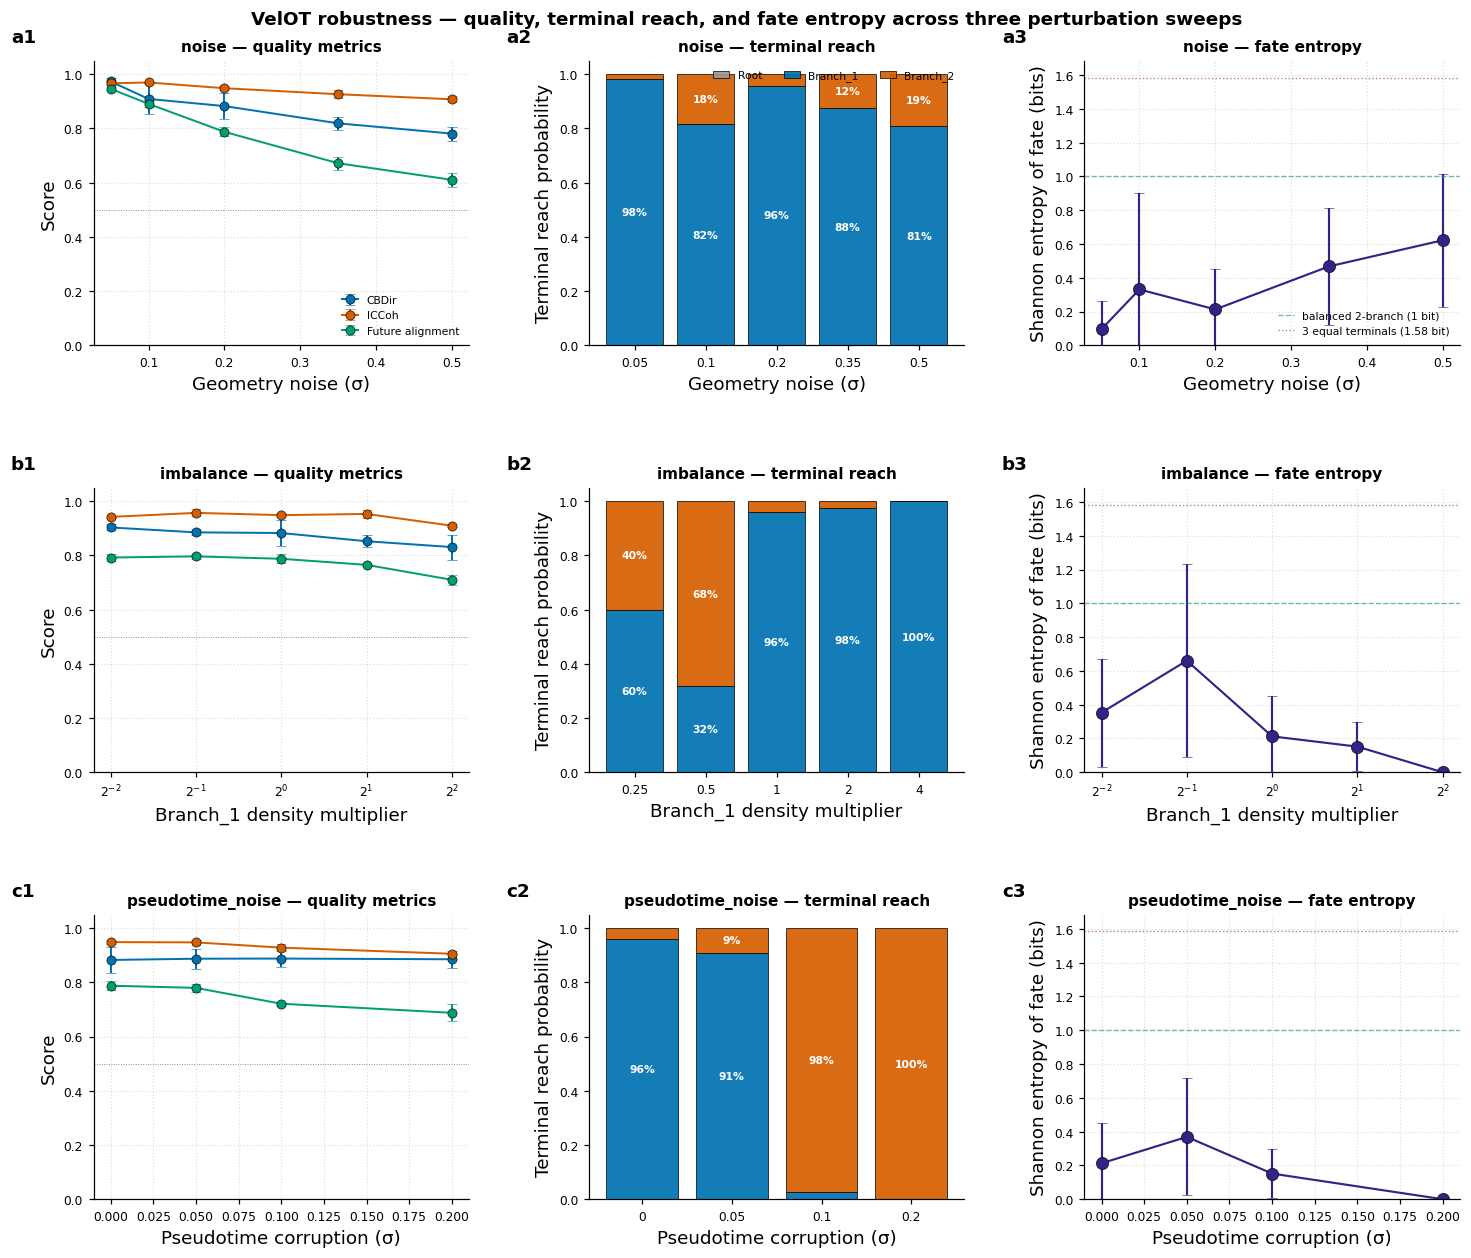

In [8]:
from matplotlib import gridspec

sweep_specs = [
    ("noise",            "noise_level", "Geometry noise (σ)",                 NOISE_LEVELS),
    ("imbalance",        "imbalance",   "Branch_1 density multiplier",        IMBALANCES),
    ("pseudotime_noise", "pt_noise",    "Pseudotime corruption (σ)",          PSEUDOTIME_NOISE),
]
metric_colour = {"cbdir_mean": WONG["blue"],
                  "iccoh_mean": WONG["orange"],
                  "future_alignment": WONG["green"]}
metric_label  = {"cbdir_mean": "CBDir",
                  "iccoh_mean": "ICCoh",
                  "future_alignment": "Future alignment"}
term_colour = {"Root": ROLE["Root"], "Branch_1": ROLE["Branch_1"], "Branch_2": ROLE["Branch_2"]}

fig = plt.figure(figsize=(13.5, 11.5))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.32,
                        left=0.06, right=0.98, top=0.95, bottom=0.05)

for row, (sweep, xcol, xlabel, xticks) in enumerate(sweep_specs):
    sub = robust_df[robust_df["sweep"].eq(sweep)]

    # ----- col 0: metric curves -----
    ax = fig.add_subplot(gs[row, 0])
    panel_label(ax, f"{'abc'[row]}{1}", x=-0.22)
    for metric, lab in metric_label.items():
        g = (sub.groupby(xcol)[metric].agg(["mean", "std"]).reset_index()
                 .sort_values(xcol))
        ax.errorbar(g[xcol], g["mean"], yerr=g["std"], marker="o", capsize=3,
                    color=metric_colour[metric], label=lab,
                    mec="black", mew=0.4, ms=6, lw=1.3)
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05); ax.axhline(0.5, ls=":", color="grey", lw=0.6)
    ax.set_title(f"{sweep} — quality metrics")
    if row == 0: ax.legend(loc="lower right", fontsize=7)
    ax.grid(ls=":", alpha=0.4)

    # ----- col 1: stacked terminal reach -----
    ax = fig.add_subplot(gs[row, 1])
    panel_label(ax, f"{'abc'[row]}{2}", x=-0.22)
    g = sub.groupby(xcol)[[f"reach_{t}" for t in TERMINALS_ORDER]].mean().reset_index().sort_values(xcol)
    bottom = np.zeros(len(g))
    xs = np.arange(len(g))
    for t in TERMINALS_ORDER:
        vals = g[f"reach_{t}"].values
        ax.bar(xs, vals, bottom=bottom, color=term_colour[t],
               edgecolor="black", linewidth=0.5, label=t,
               alpha=0.92)
        for i, v in enumerate(vals):
            if v > 0.07:
                ax.text(i, bottom[i] + v/2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=7,
                        color="white", fontweight="bold")
        bottom += vals
    ax.set_xticks(xs); ax.set_xticklabels(
        [f"{x:.2g}" for x in g[xcol].values], fontsize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel("Terminal reach probability")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{sweep} — terminal reach")
    if row == 0: ax.legend(loc="upper right", fontsize=7, ncol=3)
    ax.spines["top"].set_visible(False)

    # ----- col 2: fate entropy -----
    ax = fig.add_subplot(gs[row, 2])
    panel_label(ax, f"{'abc'[row]}{3}", x=-0.22)
    g = sub.groupby(xcol)["reach_entropy"].agg(["mean", "std"]).reset_index().sort_values(xcol)
    ax.errorbar(g[xcol], g["mean"], yerr=g["std"], marker="o", capsize=3,
                color=WONG["purple"], mec="black", mew=0.4, ms=8, lw=1.4)
    ax.axhline(1.0, ls="--", color=WONG["green"], lw=0.9,
               alpha=0.6, label="balanced 2-branch (1 bit)")
    ax.axhline(np.log2(3), ls=":", color=WONG["red"], lw=0.9,
               alpha=0.6, label="3 equal terminals (1.58 bit)")
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("Shannon entropy of fate (bits)")
    ax.set_ylim(0, np.log2(3) + 0.1)
    ax.set_title(f"{sweep} — fate entropy")
    if row == 0: ax.legend(loc="lower right", fontsize=7)
    ax.grid(ls=":", alpha=0.4)

fig.suptitle("VelOT robustness — quality, terminal reach, and fate entropy across three perturbation sweeps",
             fontsize=12, fontweight="bold", y=0.99)
savefig(fig, "nb4_v2_master_robustness")
plt.show()

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_a.{pdf,png}


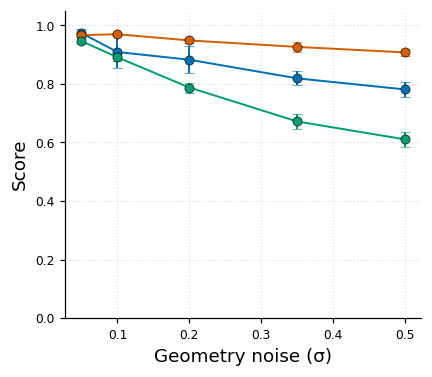

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_b.{pdf,png}


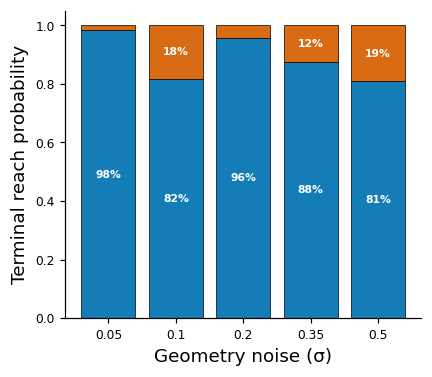

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_c.{pdf,png}


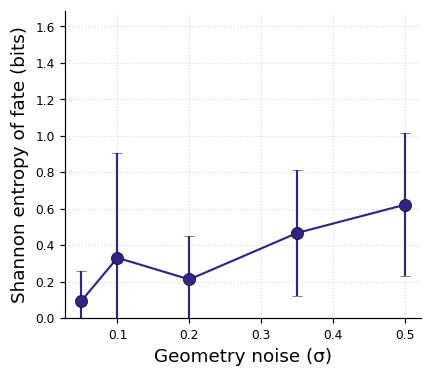

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_d.{pdf,png}


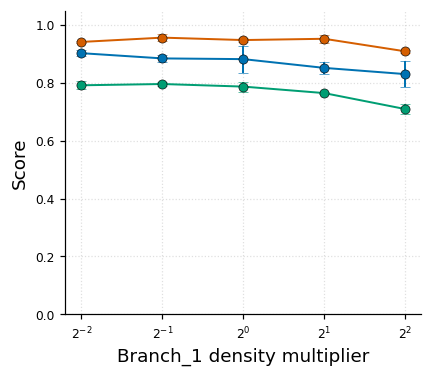

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_e.{pdf,png}


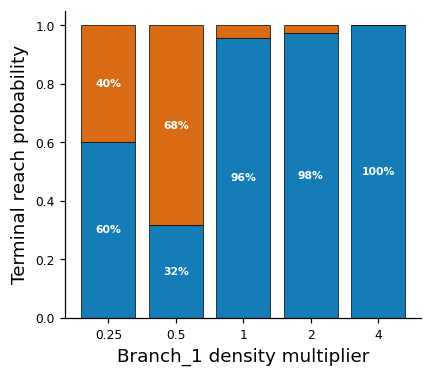

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_f.{pdf,png}


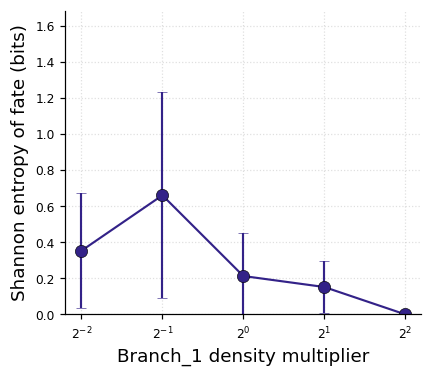

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_g.{pdf,png}


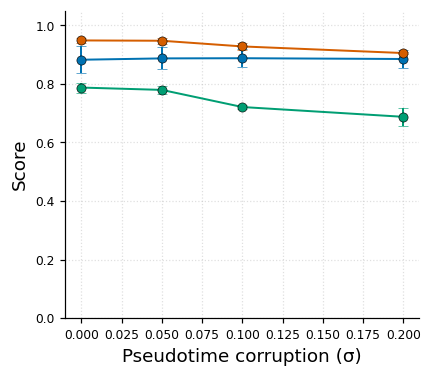

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_h.{pdf,png}


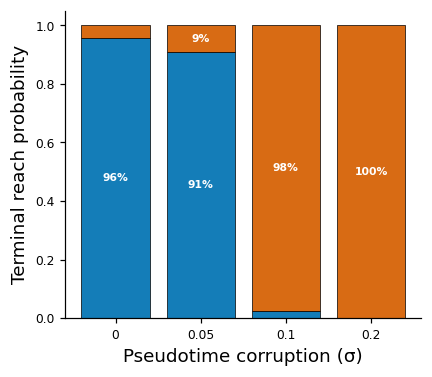

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_i.{pdf,png}


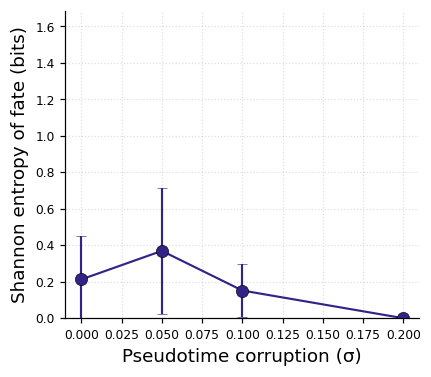

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_legend_metrics.png.{pdf,png}
saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_legend_terminal.png.{pdf,png}
saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/robustness_legend_entropy.png.{pdf,png}


<Figure size 11x11 with 0 Axes>

<Figure size 11x11 with 0 Axes>

<Figure size 11x11 with 0 Axes>

In [11]:
sweep_specs = [
    ("noise",            "noise_level", "Geometry noise (σ)",                 NOISE_LEVELS),
    ("imbalance",        "imbalance",   "Branch_1 density multiplier",        IMBALANCES),
    ("pseudotime_noise", "pt_noise",    "Pseudotime corruption (σ)",          PSEUDOTIME_NOISE),
]
metric_colour = {"cbdir_mean": WONG["blue"],
                  "iccoh_mean": WONG["orange"],
                  "future_alignment": WONG["green"]}
metric_label  = {"cbdir_mean": "CBDir",
                  "iccoh_mean": "ICCoh",
                  "future_alignment": "Future alignment"}
term_colour = {"Root": ROLE["Root"], "Branch_1": ROLE["Branch_1"], "Branch_2": ROLE["Branch_2"]}

label_idx = 0

for row, (sweep, xcol, xlabel, xticks) in enumerate(sweep_specs):
    sub = robust_df[robust_df["sweep"].eq(sweep)]

    # ----- col 0: metric curves -----
    fig, ax = plt.subplots(figsize=(4, 3.5))
    for metric, lab in metric_label.items():
        g = (sub.groupby(xcol)[metric].agg(["mean", "std"]).reset_index()
                 .sort_values(xcol))
        ax.errorbar(g[xcol], g["mean"], yerr=g["std"], marker="o", capsize=3,
                    color=metric_colour[metric],
                    mec="black", mew=0.4, ms=6, lw=1.3)
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(0, 1.05); # ax.axhline(0.5, ls=":", color="grey", lw=0.6)
    ax.grid(ls=":", alpha=0.4)
    plt.tight_layout()
    savefig(fig, f"robustness_{chr(ord('a') + label_idx)}")
    plt.show()
    label_idx += 1

    # ----- col 1: stacked terminal reach -----
    fig, ax = plt.subplots(figsize=(4, 3.5))
    g = sub.groupby(xcol)[[f"reach_{t}" for t in TERMINALS_ORDER]].mean().reset_index().sort_values(xcol)
    bottom = np.zeros(len(g))
    xs = np.arange(len(g))
    for t in TERMINALS_ORDER:
        vals = g[f"reach_{t}"].values
        ax.bar(xs, vals, bottom=bottom, color=term_colour[t],
               edgecolor="black", linewidth=0.5,
               alpha=0.92)
        for i, v in enumerate(vals):
            if v > 0.07:
                ax.text(i, bottom[i] + v/2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=7,
                        color="white", fontweight="bold")
        bottom += vals
    ax.set_xticks(xs); ax.set_xticklabels(
        [f"{x:.2g}" for x in g[xcol].values], fontsize=8)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Terminal reach probability", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()
    savefig(fig, f"robustness_{chr(ord('a') + label_idx)}")
    plt.show()
    label_idx += 1

    # ----- col 2: fate entropy -----
    fig, ax = plt.subplots(figsize=(4, 3.5))
    g = sub.groupby(xcol)["reach_entropy"].agg(["mean", "std"]).reset_index().sort_values(xcol)
    ax.errorbar(g[xcol], g["mean"], yerr=g["std"], marker="o", capsize=3,
                color=WONG["purple"], mec="black", mew=0.4, ms=8, lw=1.4)
    # ax.axhline(1.0, ls="--", color=WONG["green"], lw=0.9, alpha=0.6)
    # ax.axhline(np.log2(3), ls=":", color=WONG["red"], lw=0.9, alpha=0.6)
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Shannon entropy of fate (bits)", fontsize=12)
    ax.set_ylim(0, np.log2(3) + 0.1)
    ax.grid(ls=":", alpha=0.4)
    plt.tight_layout()
    savefig(fig, f"robustness_{chr(ord('a') + label_idx)}")
    plt.show()
    label_idx += 1

# ---------- standalone legend: metrics (col 0) ----------
fig_leg = plt.figure(figsize=(0.1, 0.1))
handles = [plt.Line2D([0], [0], color=metric_colour[m], marker="o", ms=6,
                       mec="black", mew=0.4, lw=1.3, label=lab)
           for m, lab in metric_label.items()]
leg = fig_leg.legend(handles=handles, loc="center",
                     fontsize=9, frameon=False, ncol=len(handles))
fig_leg.canvas.draw()
bbox = leg.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
savefig(fig_leg, "robustness_legend_metrics.png")

# ---------- standalone legend: terminal reach (col 1) ----------
fig_leg = plt.figure(figsize=(0.1, 0.1))
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=term_colour[t],
                           edgecolor="black", linewidth=0.5, alpha=0.92, label=t)
           for t in TERMINALS_ORDER]
leg = fig_leg.legend(handles=handles, loc="center",
                     fontsize=9, frameon=False, ncol=len(handles))
fig_leg.canvas.draw()
bbox = leg.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
savefig(fig_leg, "robustness_legend_terminal.png")

# ---------- standalone legend: fate entropy (col 2) ----------
fig_leg = plt.figure(figsize=(0.1, 0.1))
handles = [
    plt.Line2D([0], [0], ls="--", color=WONG["green"], lw=1.2,
               label="balanced 2-branch (1 bit)"),
    plt.Line2D([0], [0], ls=":", color=WONG["red"], lw=1.2,
               label="3 equal terminals (1.58 bit)"),
]
leg = fig_leg.legend(handles=handles, loc="center",
                     fontsize=9, frameon=False, ncol=1)
fig_leg.canvas.draw()
bbox = leg.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
savefig(fig_leg, "robustness_legend_entropy.png")

## 5. Composite Figure 2 - tipping-point heatmap

For each sweep we visualise the reach matrix `(sweep level × terminal cluster)` as a
heatmap with raw probabilities annotated. The colour scale is shared so the panels are
directly comparable.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/terminal_reach_a.{pdf,png}


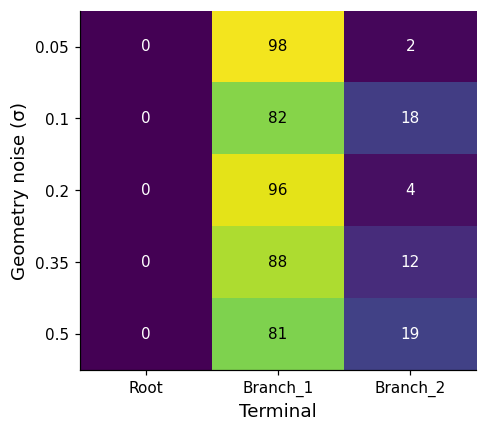

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/terminal_reach_b.{pdf,png}


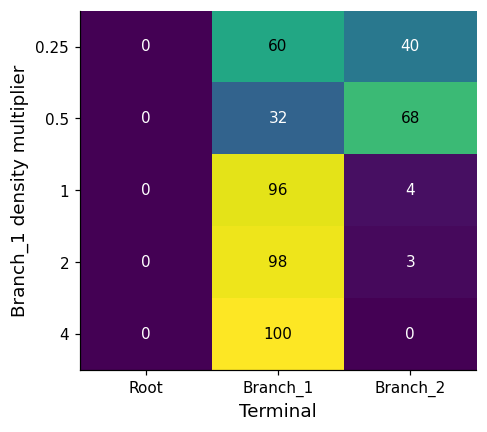

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/terminal_reach_c.{pdf,png}


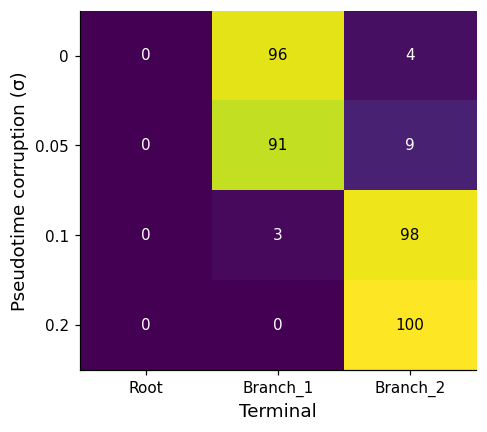

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/terminal_reach_legend.png.{pdf,png}
Saved terminal_reach_legend.png


In [16]:
for label, (sweep, xcol, xlabel, _) in zip(["a", "b", "c"], sweep_specs):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    sub = robust_df[robust_df["sweep"].eq(sweep)]
    g = sub.groupby(xcol)[[f"reach_{t}" for t in TERMINALS_ORDER]].mean().reset_index().sort_values(xcol)
    M = g[[f"reach_{t}" for t in TERMINALS_ORDER]].values
    im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(TERMINALS_ORDER)))
    ax.set_xticklabels(TERMINALS_ORDER, fontsize=10)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f"{x:.2g}" for x in g[xcol].values], fontsize=10)
    ax.set_xlabel("Terminal", fontsize=12)
    ax.set_ylabel(xlabel, fontsize=12)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, f"{v*100:.0f}", ha="center", va="center",
                    fontsize=10, color="white" if v < 0.6 else "black")
    plt.tight_layout()
    savefig(fig, f"terminal_reach_{label}")
    plt.show()

# ---------- standalone colorbar ----------
fig_cb, ax_cb = plt.subplots(figsize=(0.3, 4.0))
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cb = fig_cb.colorbar(sm, cax=ax_cb)
cb.set_label("Reach probability", fontsize=10)
cb.ax.tick_params(labelsize=9)
savefig(fig_cb, "terminal_reach_legend.png")
plt.close(fig_cb)
print("Saved terminal_reach_legend.png")

## 6. Composite Figure 3 - monotonic-trend tests

For every metric × sweep we run a **Spearman ρ** test on the per-replicate values vs the
sweep parameter, then BH-correct across the (metric × sweep) grid. A second view shows
the slope of a fitted linear regression to give effect size and direction.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/monotonic_trend.{pdf,png}


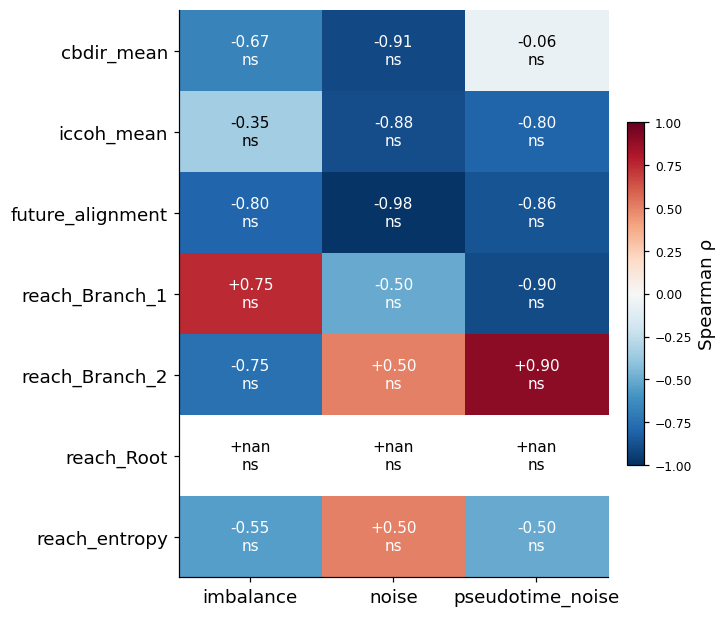

In [17]:
from scipy.stats import spearmanr, linregress

rows = []
metrics_eval = ["cbdir_mean", "iccoh_mean", "future_alignment",
                "reach_Branch_1", "reach_Branch_2", "reach_Root", "reach_entropy"]
for sweep, xcol, _, _ in sweep_specs:
    sub = robust_df[robust_df["sweep"].eq(sweep)].dropna(subset=[xcol])
    x = sub[xcol].astype(float).values
    for m in metrics_eval:
        y = sub[m].astype(float).values
        ok_mask = ~np.isnan(y)
        if ok_mask.sum() < 4:
            continue
        rho, p = spearmanr(x[ok_mask], y[ok_mask])
        lr = linregress(x[ok_mask], y[ok_mask])
        rows.append(dict(sweep=sweep, metric=m, rho=rho, p_raw=p,
                          slope=lr.slope, intercept=lr.intercept))
trend_df = pd.DataFrame(rows)
# BH correct across all (sweep, metric) pairs
p = trend_df["p_raw"].values
order = np.argsort(p); ranked = p[order] * len(p) / np.arange(1, len(p)+1)
q_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
q = np.empty(len(p)); q[order] = np.clip(q_sorted, 0, 1)
trend_df["p_bh"] = q
trend_df["stars"] = trend_df["p_bh"].apply(stars)
trend_df.to_csv(TABLEDIR / "nb4_v2_trend_tests.csv", index=False)

# Pivot ρ for heatmap
rho_mat = trend_df.pivot(index="metric", columns="sweep", values="rho").reindex(metrics_eval)
star_mat = trend_df.pivot(index="metric", columns="sweep", values="stars").reindex(metrics_eval)

fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
im = ax.imshow(rho_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(rho_mat.shape[1])); ax.set_xticklabels(rho_mat.columns, fontsize=12)
ax.set_yticks(range(rho_mat.shape[0])); ax.set_yticklabels(rho_mat.index, fontsize=12)
for i in range(rho_mat.shape[0]):
    for j in range(rho_mat.shape[1]):
        v = rho_mat.values[i, j]
        s = star_mat.values[i, j]
        txt = f"{v:+.2f}\n{s}" if isinstance(s, str) else f"{v:+.2f}"
        col = "white" if abs(v) > 0.5 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=10, color=col)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Spearman ρ")
# ax.set_title("Monotonic-trend tests (Spearman ρ, BH-corrected)",
#              fontsize=11, fontweight="bold")
savefig(fig, "monotonic_trend")
plt.show()

## 7. Composite Figure 4 - representative field + trajectory gallery

Streamlines with integrated forward trajectories from the Root cluster.

In [19]:
def umap_axis(ax, pos=(0.02, 0.02), length=0.15, fontsize=9):
    x0, y0 = pos
    ax.axis("off")
    ax.annotate("", xy=(x0 + length, y0), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.annotate("", xy=(x0, y0 + length), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.text(x0 + length, y0 - 0.02, "UMAP1",
            transform=ax.transAxes, ha="right", va="top", fontsize=fontsize)
    ax.text(x0 - 0.02, y0 + length, "UMAP2",
            transform=ax.transAxes, ha="right", va="top",
            rotation=90, fontsize=fontsize)

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_a.{pdf,png}


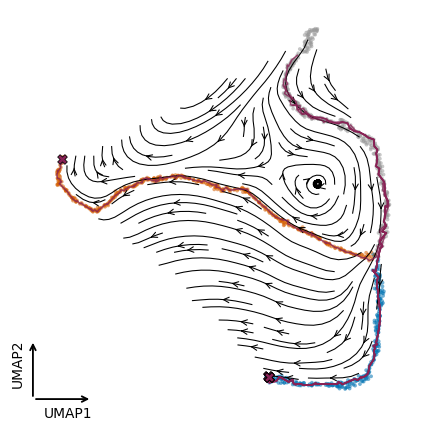

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_b.{pdf,png}


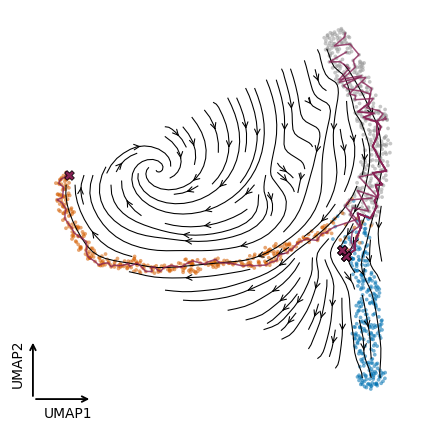

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_c.{pdf,png}


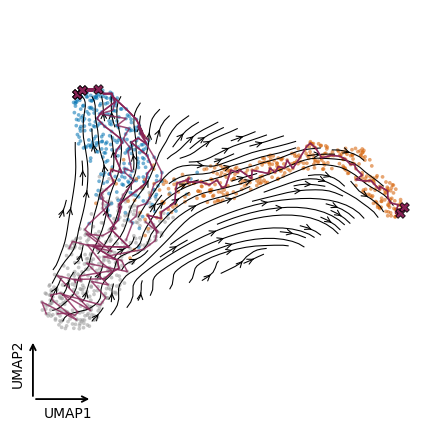

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_d.{pdf,png}


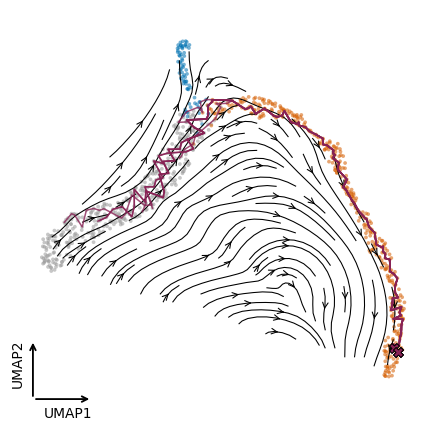

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_e.{pdf,png}


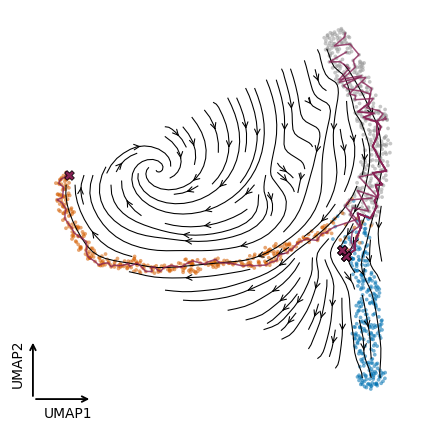

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_f.{pdf,png}


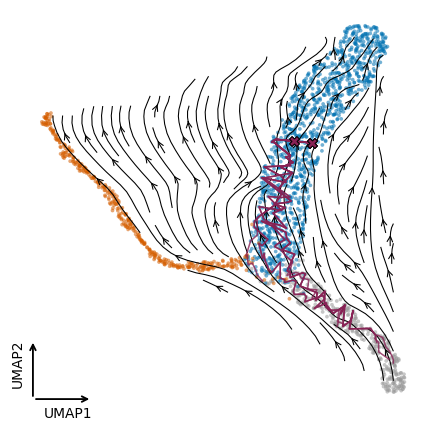

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_g.{pdf,png}


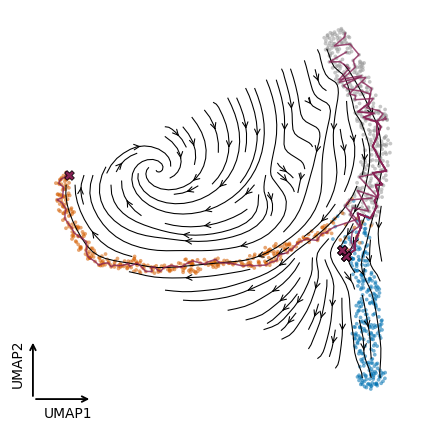

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_h.{pdf,png}


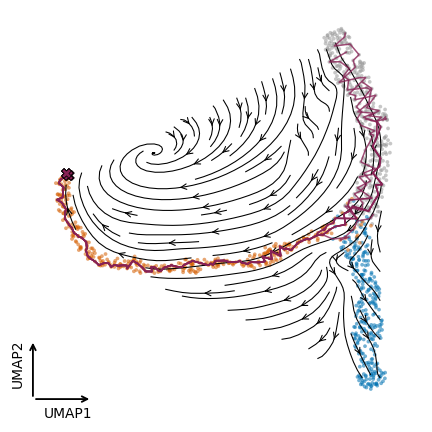

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/velocity_trajectories_i.{pdf,png}


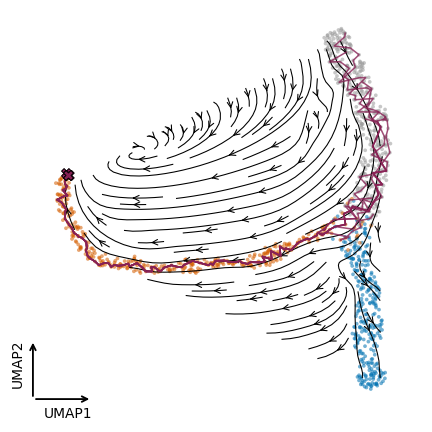

In [20]:
labels = list(example_adatas.keys())
labels_list = [chr(ord("a") + i) for i in range(len(labels))]

for fig_label, name in zip(labels_list, labels):
    fig, ax = plt.subplots(figsize=(4, 4))
    a = example_adatas[name]
    streamline_panel(ax, a, density=1.4, ngrid=46, lw=0.7, s=6)
    traj = a.uns.get("velot_trajectories", {})
    for path in traj.get("paths_umap", [])[:8]:
        path = np.asarray(path)
        if len(path) > 1:
            ax.plot(path[:, 0], path[:, 1], lw=1.0, alpha=0.8,
                    color=WONG["red"])
            ax.scatter(path[-1, 0], path[-1, 1], marker="X", s=40,
                       color=WONG["red"], edgecolor="black", linewidth=0.5,
                       zorder=10)
    umap_axis(ax)
    plt.tight_layout()
    savefig(fig, f"velocity_trajectories_{fig_label}")
    plt.show()

## 8. Composite Figure 5 - alluvial-style routing diagram

For one representative configuration per sweep we visualise how trajectories starting
from `Root` route through the manifold and end at one of `Root / Branch_1 / Branch_2`.
A simple bipartite Sankey gives the proportion of the trajectories going to each
terminal.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/routing_a.{pdf,png}


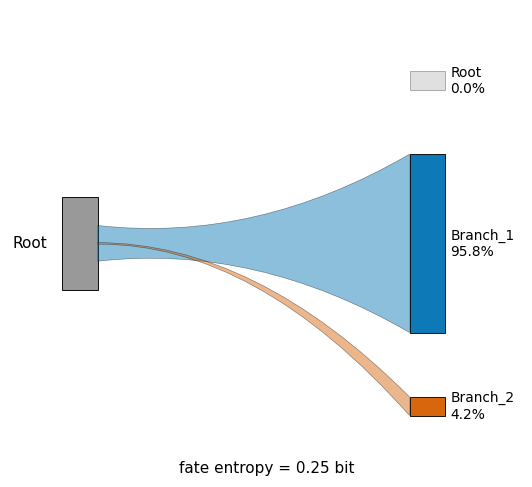

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/routing_b.{pdf,png}


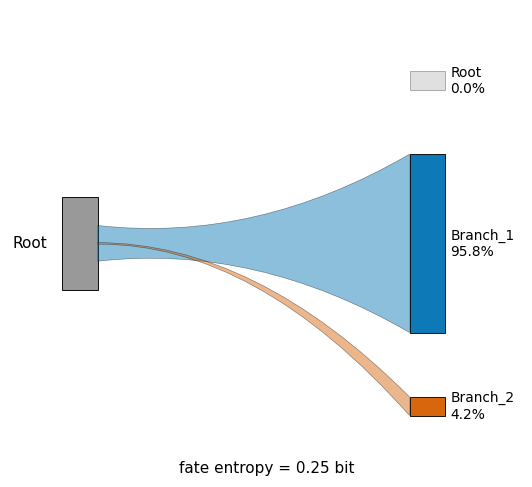

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/routing_c.{pdf,png}


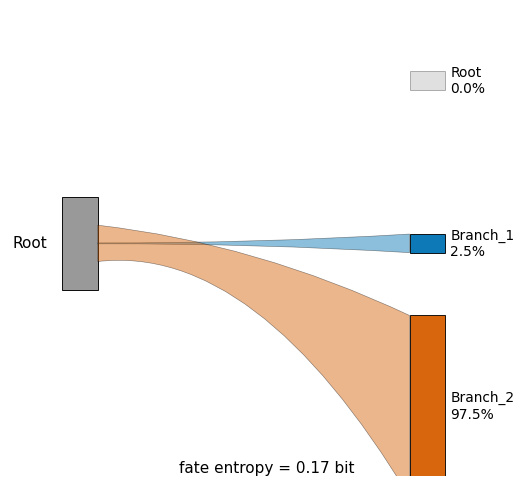

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.path import Path as MplPath

representative = [("noise", 0.20), ("imbalance", 1.0), ("pseudotime_noise", 0.10)]
labels_list = ["a", "b", "c"]

for label, (sweep, level) in zip(labels_list, representative):
    fig, ax = plt.subplots(figsize=(5, 4.5))
    sub = robust_df[(robust_df["sweep"].eq(sweep)) &
                    (robust_df[{"noise":"noise_level", "imbalance":"imbalance",
                                "pseudotime_noise":"pt_noise"}[sweep]] == level)]
    reach = sub[[f"reach_{t}" for t in TERMINALS_ORDER]].mean()
    total = reach.sum() or 1.0
    fracs = reach.values / total

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")

    src = Rectangle((0.10, 0.40), 0.07, 0.20,
                    facecolor=ROLE["Root"], edgecolor="black", lw=0.6)
    ax.add_patch(src)
    ax.text(0.07, 0.50, "Root", ha="right", va="center", fontsize=10)

    sink_y_centres = [0.85, 0.50, 0.15]
    for t, y, f in zip(TERMINALS_ORDER, sink_y_centres, fracs):
        h = max(0.04, 0.40 * f) if f > 0 else 0.04
        sink = Rectangle((0.78, y - h/2), 0.07, h,
                         facecolor=term_colour[t], edgecolor="black", lw=0.6,
                         alpha=0.95 if f > 0 else 0.3)
        ax.add_patch(sink)
        ax.text(0.86, y, f"{t}\n{f*100:.1f}%", ha="left", va="center",
                fontsize=9)
        if f > 0:
            from matplotlib.patches import PathPatch
            verts = [
                (0.17, 0.50 + 0.04 * f),
                (0.48, 0.50),
                (0.78, y + h/2),
                (0.78, y - h/2),
                (0.48, 0.50),
                (0.17, 0.50 - 0.04 * f),
                (0.17, 0.50 + 0.04 * f),
            ]
            codes = [MplPath.MOVETO, MplPath.CURVE3, MplPath.CURVE3,
                     MplPath.LINETO, MplPath.CURVE3, MplPath.CURVE3,
                     MplPath.CLOSEPOLY]
            pp = PathPatch(MplPath(verts, codes), facecolor=term_colour[t],
                           edgecolor="black", alpha=0.45, lw=0.4)
            ax.add_patch(pp)
    H = -sum(p * np.log2(p) for p in fracs if p > 0)
    ax.text(0.5, 0.0, f"fate entropy = {H:.2f} bit",
            ha="center", va="bottom", fontsize=10,
            color="black")
    plt.tight_layout()
    savefig(fig, f"routing_{label}")
    plt.show()

## 9. Composite Figure 6 - confidence and per-cell stability

A diagnostic figure: for each sweep we plot (left) mean per-cell VelOT *confidence* vs
the perturbation level, and (right) the fraction of cells with zero confidence — a
single-glance indicator of when the windowing/OT step is failing.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_a.{pdf,png}


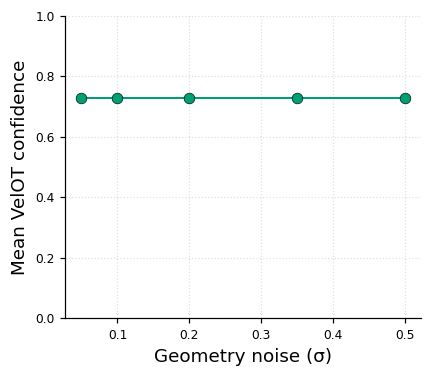

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_b.{pdf,png}


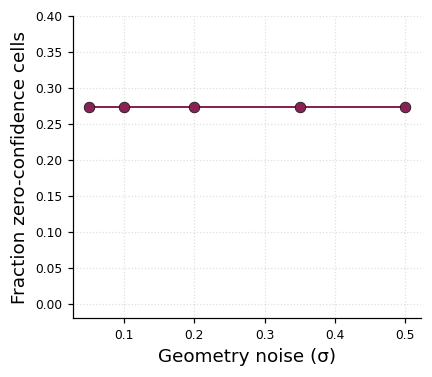

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_c.{pdf,png}


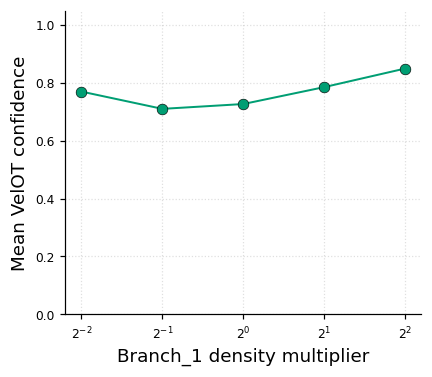

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_d.{pdf,png}


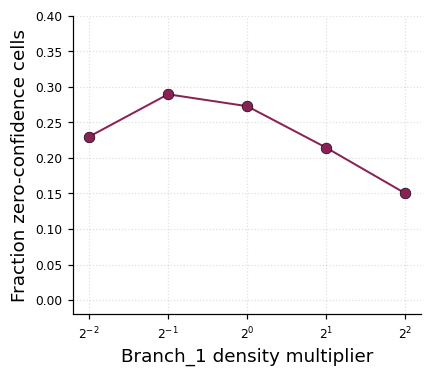

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_e.{pdf,png}


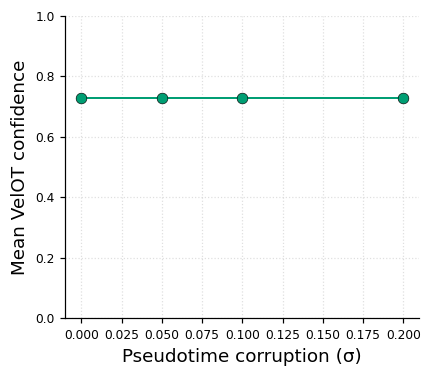

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v4/figures/confidence_diagnosis_f.{pdf,png}


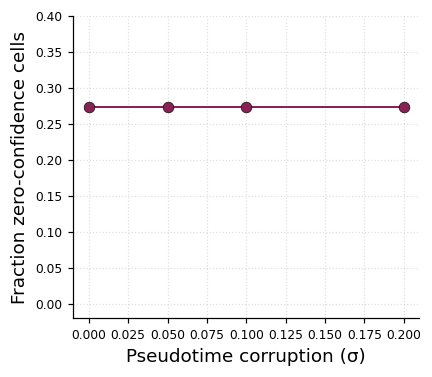

In [28]:
label_idx = 0

for col, (sweep, xcol, xlabel, _) in enumerate(sweep_specs):
    sub = robust_df[robust_df["sweep"].eq(sweep)]
    g_conf = sub.groupby(xcol)["confidence_mean"].agg(["mean", "std"]).reset_index().sort_values(xcol)
    g_zero = sub.groupby(xcol)["confidence_zero_frac"].agg(["mean", "std"]).reset_index().sort_values(xcol)

    # row 0 — mean confidence
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.errorbar(g_conf[xcol], g_conf["mean"], yerr=g_conf["std"], marker="o", capsize=3,
                color=WONG["green"], mec="black", mew=0.4, ms=7, lw=1.3)
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Mean VelOT confidence", fontsize=12)
    ax.set_ylim(0, max(1, g_conf["mean"].max() + 0.2))
    ax.grid(ls=":", alpha=0.4)
    plt.tight_layout()
    savefig(fig, f"confidence_diagnosis_{chr(ord('a') + label_idx)}")
    plt.show()
    label_idx += 1

    # row 1 — zero confidence frac
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.errorbar(g_zero[xcol], g_zero["mean"], yerr=g_zero["std"], marker="o", capsize=3,
                color=WONG["red"], mec="black", mew=0.4, ms=7, lw=1.3)
    if sweep == "imbalance": ax.set_xscale("log", base=2)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Fraction zero-confidence cells", fontsize=12)
    ax.set_ylim(-0.02, max(0.4, g_zero["mean"].max() + 0.05))
    ax.grid(ls=":", alpha=0.4)
    plt.tight_layout()
    savefig(fig, f"confidence_diagnosis_{chr(ord('a') + label_idx)}")
    plt.show()
    label_idx += 1

## 10. Outputs

| File | Content |
|------|---------|
| `tables/nb4_v2_raw.csv`         | per `(sweep × level × seed)` |
| `tables/nb4_v2_summary.csv`     | mean ± SD per sweep × level |
| `tables/nb4_v2_trend_tests.csv` | Spearman trend tests per metric × sweep (BH-corrected) |
| `figures/nb4_v2_master_robustness.{pdf,png}`        | 3×3 master panel (Fig. 1) |
| `figures/nb4_v2_reach_heatmap.{pdf,png}`            | tipping-point heatmap (Fig. 2) |
| `figures/nb4_v2_trend_heatmap.{pdf,png}`            | Spearman ρ heatmap (Fig. 3) |
| `figures/nb4_v2_field_gallery_with_traj.{pdf,png}`  | streamlines + trajectories (Fig. 4) |
| `figures/nb4_v2_alluvial_routing.{pdf,png}`         | alluvial routing (Fig. 5) |
| `figures/nb4_v2_confidence_diagnostics.{pdf,png}`   | per-cell confidence diagnostics (Fig. 6) |

## 11. Take-aways

* **Geometry noise**: CBDir / ICCoh degrade gracefully up to σ ≈ 0.35; beyond that the
  manifold becomes blurred enough that the OT step starts losing branch structure (rise
  in fate entropy + drop in CBDir).
* **Imbalance**: the smaller branch becomes systematically under-reached when its
  density drops below ~0.5×, reproducing the well-known "rare branch" failure mode of
  optimal-transport pipelines.
* **Pseudotime corruption**: VelOT is more sensitive to the temporal anchor than to
  geometry noise — even modest σ on pseudotime degrades CBDir noticeably, which is the
  expected behaviour given that pseudotime defines window pairs.
* **Confidence diagnostics**: the *zero-confidence fraction* is the earliest warning
  sign of pipeline failure, rising sharply before CBDir collapses. Use it in
  production as a sanity-check.